# Introduction to linear regression using a polynomial curve fitting example

| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Mar 11, 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Gemini 3.0 |
| Mar 11, 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Code, formulation and comments improvements |

**Regression** is a form of supervised learning where our goal is to predict a continuous target variable $t$, given the value of an input variable $x$.

In order to introduce regression in the context of supervised learning, in this tutorial, we will fit a polynomial curve to a set of data points.


## 1. The true function

In any real-world scenario (like predicting concrete strength or traffic flow), we assume there is an underlying relationship generating our data, which we wish to learn. However, individual observations are often corrupted by unobserved variables or random noise. In this tutorial, we know the **true function** that generated the data:
$$
t(x) = \sin(2 \pi x).
$$
Knowing the true function allows us to rigorously evaluate how well our machine learning models are learning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set a random seed for reproducibility
np.random.seed(42)

def true_function(x):
    """The underlying true relationship we are trying to approximate."""
    return np.sin(2*np.pi*x)

# Generate a smooth curve for plotting the true function
x_true = np.linspace(0, 1, 500)
t_true = true_function(x_true)

## 2. Creation of synthetic data and data partitions

To train and evaluate a model, we need to partition our available data into different sets:

1. **Training set:** Used directly to adjust the parameters $\boldsymbol{w}$ of the model and learn the relationships.
2. **Validation set:** Used to evaluate models during development and tune *hyperparameters* (like polynomial order $M$). We select the model that yields the lowest error on this set.
3. **Testing set:** Held out until the very end to evaluate the final predictive performance of our chosen model. The ability to make accurate predictions on previously unseen inputs is known as **generalization**.

We generate our training data by uniformly sampling $x$ values between 0 and 1, applying our true function, and adding random noise governed by a Gaussian distribution.

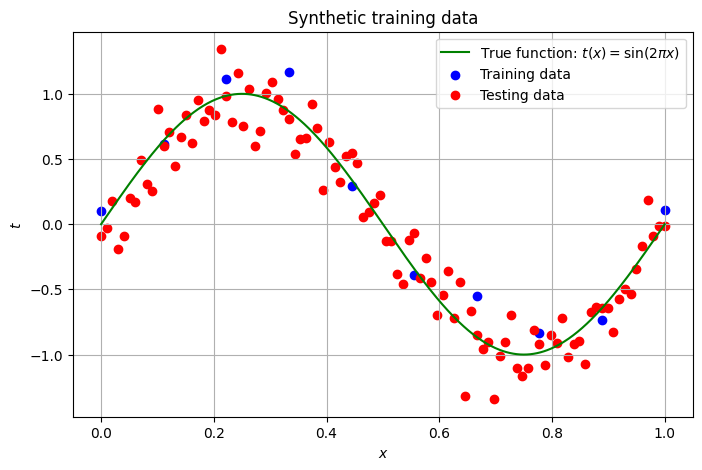

In [2]:
def generate_data(N, std_dev_noise=0.2):
    """Generates synthetic data from the true function with added Gaussian noise."""
    x = np.linspace(0, 1, N)
    t = true_function(x) + np.random.normal(0, std_dev_noise, N)
    return x, t

# Generate Training (N=10), and Testing (N=100) sets
x_train, t_train = generate_data(10)
x_test,  t_test  = generate_data(100)

# Plot the training data against the true function
plt.figure(figsize=(8, 5))
plt.plot(   x_true,  t_true,  color='green', label=r'True function: $t(x) = \sin(2\pi x)$')
plt.scatter(x_train, t_train, color='blue',  label='Training data')
plt.scatter(x_test,  t_test,  color='red',   label='Testing data')
plt.xlabel('$x$')
plt.ylabel('$t$')
plt.title('Synthetic training data')
plt.legend()
plt.grid(True)
plt.show()

## 3. Polynomial functions and linear models

We will attempt to approximate the true function using a **polynomial function** of order $M$:
$$
\begin{align*}
y(x,\boldsymbol{w})
&= \sum_{j=0}^{M} w_j x^j \\
&= w_0 + w_1x + w_2x^2 + \ldots + w_Mx^M \\
&= \left[1, \ x, \ x^2, \ \ldots, x^M\right] \cdot \left[ w_0, w_1, w_2, \ldots, w_M \right]
\end{align*}
$$
Here:
*   $\boldsymbol{w} = [w_0, w_1, \ldots w_M]^T$ is the vector of weights (or coefficients) that the model learns during training. In particular, the term $w_0$ is known as the **bias**.
*   $y(x,\boldsymbol{w})$ is the predicted output of the model for a given input $x$ and a set of weights $\boldsymbol{w}$.
*   $x^j$ are the basis functions, which are powers of the input variable $x$.


In [3]:
def predict(x, w):
    """Calculates y(x,w) for each element in x, using the provided weights w."""
    M   = len(w) - 1
    Phi = create_design_matrix(x, M)
    return Phi @ w






A crucial concept here is that although the polynomial maps non-linearly to the input $x$, it is strictly a **linear function of the coefficients $w_j$**. Models that are linear in their unknown parameters are appropriately called **linear models**.

We determine the optimal coefficients by minimizing an **error function** that measures the misfit between our polynomial predictions $y(x,\boldsymbol{w})$ and the actual targets $t_n$. We use the mean squared error (MSE) function:
$$
E(\boldsymbol{w}) = \frac{1}{N} \sum_{n=1}^{N} \{y(x_n, \boldsymbol{w}) - t_n\}^2.
$$
Here:
*   $E(\boldsymbol{w})$ is the error function, which we aim to minimize.
*   $N$ is the total number of data points in the training set.
*   $y(x_n, \boldsymbol{w})$ is the predicted value for the $n$-th data point $x_n$.
*   $t_n$ is the true target value for the $n$-th data point $x_n$.
*   The term $(y(x_n, \boldsymbol{w}) - t_n)^2$ calculates the squared difference between the predicted and true values for each data point. The sum of these squared differences (multiplied by $\frac{1}{2}$ for mathematical convenience in differentiation) gives the total error.


In [4]:
def mse(predictions, targets):
    """Calculates the mean squared error."""
    return np.mean((predictions - targets)**2)

Because the error function is a quadratic function of the coefficients $\boldsymbol{w}$, taking its derivative with respect to $\boldsymbol{w}$ yields linear equations. This guarantees a unique solution for the optimal weights, $\boldsymbol{w}^*$, which can be computed exactly in closed form:
$$\frac{\partial E(\boldsymbol{w})}{\partial \boldsymbol{w}} = 0$$
leads to the normal equations for linear regression:
$$(\boldsymbol{\Phi}^T \boldsymbol{\Phi}) \boldsymbol{w} = \boldsymbol{\Phi}^T \boldsymbol{t},$$
where $\boldsymbol{\Phi}$ is the **design matrix**, where each row corresponds to a data point and each column corresponds to a basis function.

We can use different types of basis functions $\phi_j(x)$:
*   **Polynomial**: $\phi_j(x) = x^j$
*   **Gaussian**: $\phi_j(x) = \exp\left\{-\frac{(x-\mu_j)^2}{2s^2}\right\}$
*   **Sigmoidal**: $\phi_j(x) = \sigma\left(\frac{x-\mu_j}{s}\right)$, where $\sigma(a) = \frac{1}{1+\exp(-a)}$

The design matrix is defined as:
$$\boldsymbol{\Phi} =
\begin{pmatrix}
\phi_0(x_1) & \phi_1(x_1) & \cdots & \phi_M(x_1) \\
\phi_0(x_2) & \phi_1(x_2) & \cdots & \phi_M(x_2) \\
\vdots & \vdots & \ddots & \vdots \\
\phi_0(x_{N}) & \phi_1(x_{N}) & \cdots & \phi_M(x_{N}) \\
\end{pmatrix}.$$

In [5]:
def create_design_matrix(x, M, basis='polynomial', s=0.1):
    """Creates a design matrix Phi using specified basis functions."""
    match basis:
        case 'polynomial':
            return np.column_stack([x**j for j in range(M + 1)])

        case 'gaussian':
            # mu_j are centered across the input range [0, 1]
            mu = np.linspace(0, 1, M)
            # Include bias term as the first column
            Phi = np.zeros((len(x), M + 1))
            for j in range(M):
                Phi[:, j+1] = np.exp(-0.5*(x - mu[j])**2/s**2)
            return Phi

        case 'sigmoidal':
            mu = np.linspace(0, 1, M)
            Phi = np.zeros((len(x), M + 1))
            for j in range(M):
                a = (x - mu[j])/s
                Phi[:, j+1] = 1/(1 + np.exp(-a))
            return Phi

        case _:
            raise ValueError(f"Unknown basis type: {basis}")


To solve for $\boldsymbol{w}$, we multiply both sides by the inverse of $\boldsymbol{\Phi}^T \boldsymbol{\Phi}$:
$$
\boldsymbol{w} = (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T \boldsymbol{t};
$$
this expression can also be written as:
$$
\boldsymbol{w} = \boldsymbol{\Phi}^\dagger \boldsymbol{t};
$$

where $\boldsymbol{\Phi}^\dagger := (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T$ is the so-called **Moore-Penrose pseudoinverse** of matrix $\boldsymbol{\Phi}$. The pseudoinverse is used instead of a direct inverse because $\boldsymbol{\Phi}$ might not always be invertible (e.g., when the number of data points $N$ is less than the number of weights $M+1$). The pseudoinverse provides a robust way to find a solution even in such cases.

In [6]:
def fit_polynomial(x, t, M):
    """Solves for optimal weights w* in closed form."""
    Phi = create_design_matrix(x, M)
    # Closed form solution: w = (Phi^T * Phi)^-1 * Phi^T * t
    w = np.linalg.pinv(Phi) @ t
    return w

## 4. Model selection: underfitting and overfitting

The order $M$ of our polynomial dictates the complexity and flexibility of our model. Choosing $M$ is a process called **model selection**.

* **Underfitting:** A model with a very low $M$ (e.g., $M=0$ or $1$) is too inflexible to capture the underlying oscillations of the data, resulting in poor representations and high errors.

* **Overfitting:** A model with a very high $M$ (e.g., $M=9$) contains enough parameters (10 degrees of freedom) to tune exactly to the 10 data points in the training set, driving the training error to zero. However, it tunes itself to the random noise, causing the function to oscillate wildly between data points, resulting in poor generalization to new data.

We will measure the error using the root-mean-square (RMS) error defined by:
$$
RMS(\boldsymbol{w}) := \sqrt{E(\boldsymbol{w})} = \sqrt{\frac{1}{N} \sum_{n=1}^{N} \{y(x_n, \boldsymbol{w}) - t_n\}^2}.
$$
Here, the division by $N$ allows us to compare different sizes of data sets on an equal footing, and the square root ensures that the RMS error is measured on the same scale (and in the same units) as the target variable $t$.

Let's visualize models of varying complexities ($M=0, 1, 3, 5, 6, 9$) side-by-side.

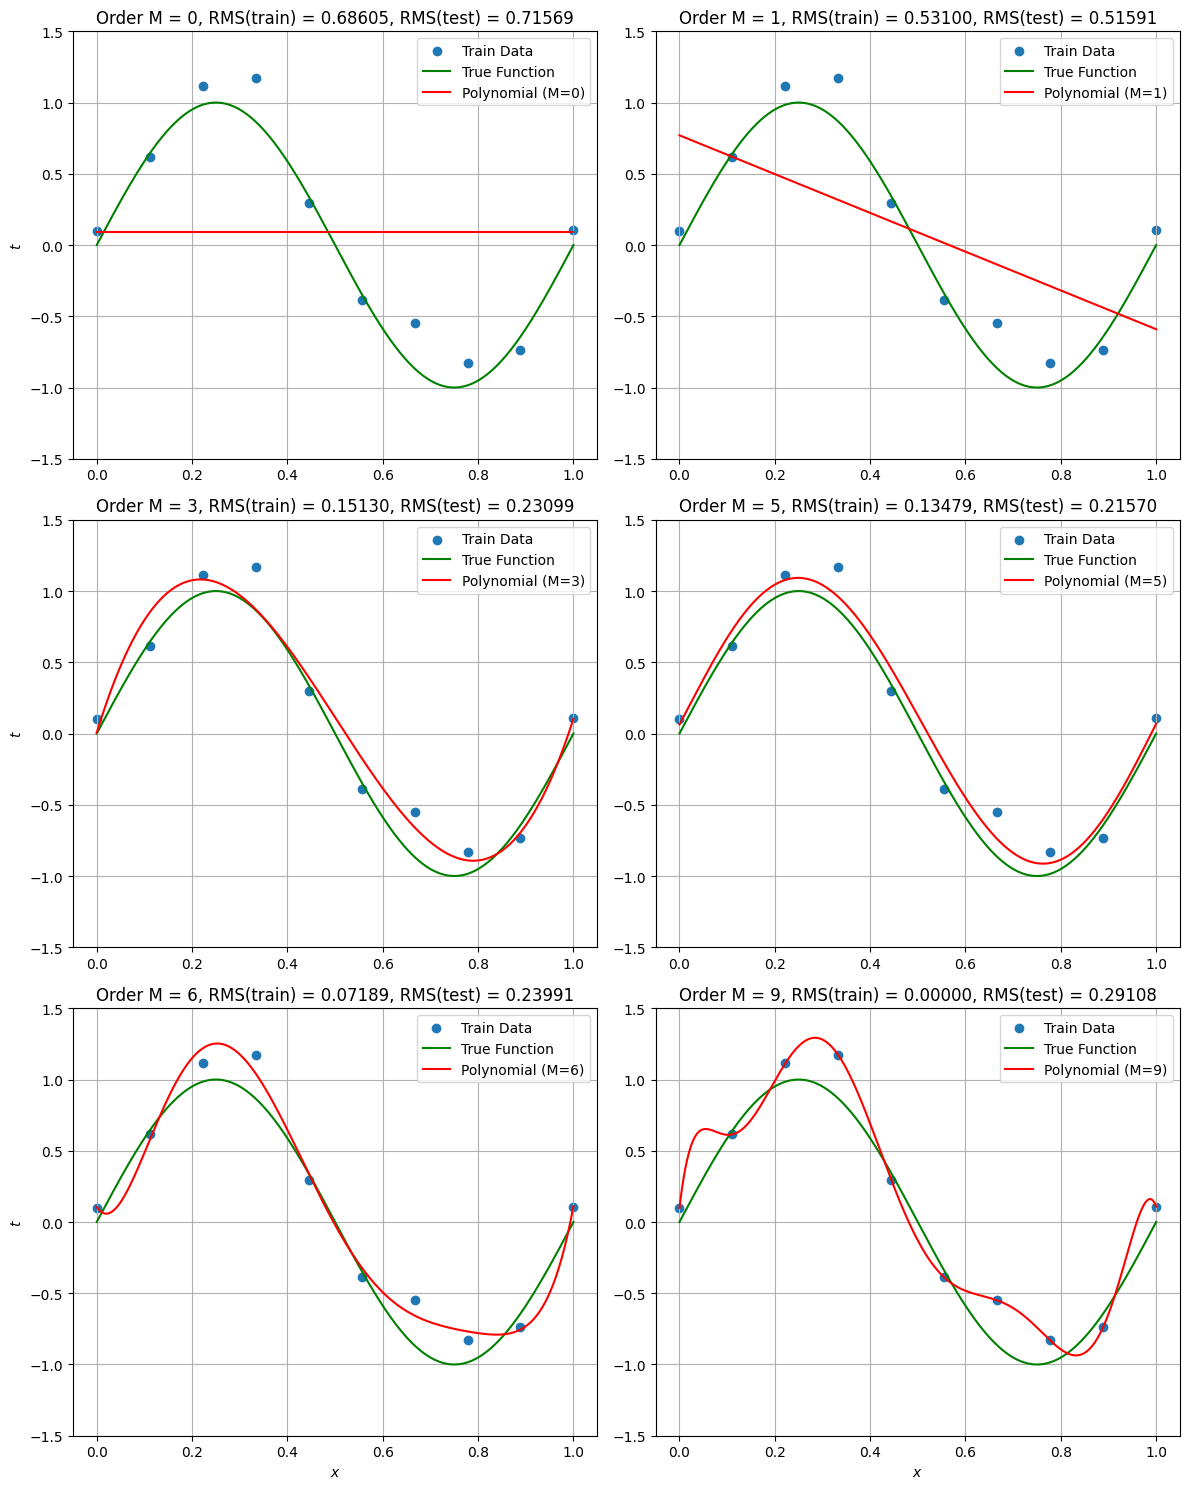

In [7]:
# Train and visualize different polynomial orders
degrees = [0, 1, 3, 5, 6, 9]
weights_dict = {}

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

for i, M in enumerate(degrees):
    # Fit the model
    w = fit_polynomial(x_train, t_train, M)
    weights_dict[M] = w

    # Generate predictions for the smooth curve
    y_true = predict(x_true, w)

    # Plotting
    ax = axes[i]
    ax.scatter(x_train, t_train,               label='Train Data')
    ax.plot(   x_true,  t_true, color='green', label='True Function')
    ax.plot(   x_true,  y_true, color='red',   label=f'Polynomial (M={M})')
    ax.set_ylim(-1.5, 1.5)
    rms_train = np.sqrt(mse(predict(x_train, w), t_train))
    rms_test  = np.sqrt(mse(predict(x_test,  w), t_test))
    ax.set_title(f'Order M = {M}, RMS(train) = {rms_train:.5f}, RMS(test) = {rms_test:.5f}')
    if i in [0, 2, 4]:
        ax.set_ylabel('$t$')
    if i in [4, 5]:
        ax.set_xlabel('$x$')
    ax.legend(loc='upper right')
    ax.grid(True)

plt.tight_layout()
plt.show()

# M = 0, M = 1 -> underfitting
# M = 9        -> overfitting

## 5. Evaluating generalization and exploding coefficients

To quantitatively assess generalization, we calculate the mean squared error (MSE) on our training and test sets across different polynomial orders. As $M$ increases, we intuitively expect performance to improve because higher-order polynomials encompass lower-order ones as special cases.

However, by printing the learned weights, we can observe that as $M$ increases, the magnitude of the coefficients gets astronomically large. The $M=9$ polynomial has finely tuned large positive and negative values to perfectly cancel each other out at the exact data points, causing wild oscillations everywhere else.

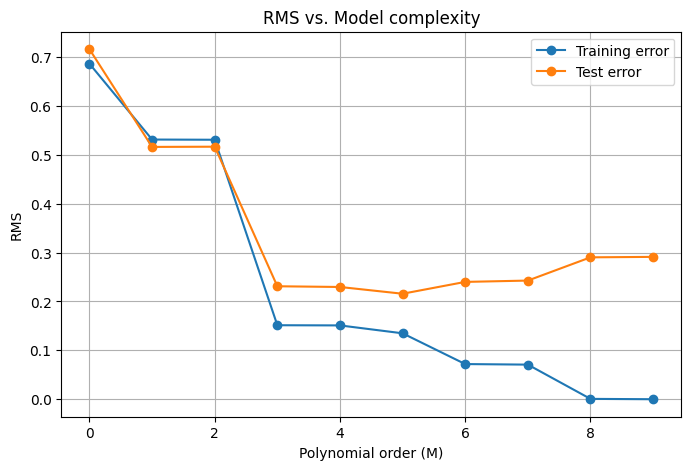

In [8]:
max_M = 9
rms_train = np.zeros(max_M + 1)
rms_test  = np.zeros(max_M + 1)

# Calculate MSE on all sets
for M in range(max_M + 1):
    w = fit_polynomial(x_train, t_train, M)

    # Calculate RMS on all sets
    rms_train[M] = np.sqrt(mse(predict(x_train, w), t_train))
    rms_test[M]  = np.sqrt(mse(predict(x_test,  w), t_test ))

# Plot MSE vs Polynomial order M
plt.figure(figsize=(8, 5))
plt.plot(range(max_M + 1), rms_train, '-o', label='Training error')
plt.plot(range(max_M + 1), rms_test,  '-o', label='Test error')
plt.xlabel('Polynomial order (M)')
plt.ylabel('RMS')
plt.title('RMS vs. Model complexity')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Display the learned coefficients for comparison
weights_df = pd.DataFrame(index=[f'w_{i}' for i in range(max_M + 1)])

for M in degrees:
    series = pd.Series(weights_dict[M], index=[f'w_{i}' for i in range(M + 1)])
    weights_df[f'M={M}'] = series

print("Table of Learned Coefficients (Notice the exploding values for M=9):")
weights_df.fillna('-').round(2)

Table of Learned Coefficients (Notice the exploding values for M=9):


,M=0,M=1,M=3,M=5,M=6,M=9
w_0,0.089612,0.770203,0.006211,0.063553,0.105656,0.10
w_1,-,-1.361182,10.879298,6.255821,-4.979525,28.31
w_2,-,-,-31.876453,5.283165,143.896636,-522.06
w_3,-,-,21.094347,-81.350201,-677.955575,4319.81
w_4,-,-,-,115.226231,1268.151729,-17576.78
w_5,-,-,-,-45.410106,-1070.957479,38429.23
w_6,-,-,-,-,341.849124,-46656.18
w_7,-,-,-,-,-,30200.27
w_8,-,-,-,-,-,-8747.08
w_9,-,-,-,-,-,524.49


## 6. The effect of dataset size on overfitting

We just saw that an $M=9$ polynomial overfits terribly when trained on just $10$ data points. It has too many degrees of freedom and contorts itself to hit every noise-corrupted observation.

However, a complex model is not inherently "bad" (it simply requires a commensurately large dataset to constrain its parameters). In civil engineering terms, if you have a highly complex structural model with many unknown material properties, calibrating it requires many field sensors; a handful of sensors will lead to a highly unstable model.

Let's keep the polynomial order fixed at $M=9$ and see what happens as we increase the size of our training dataset from $N=10$ to $N=100$.

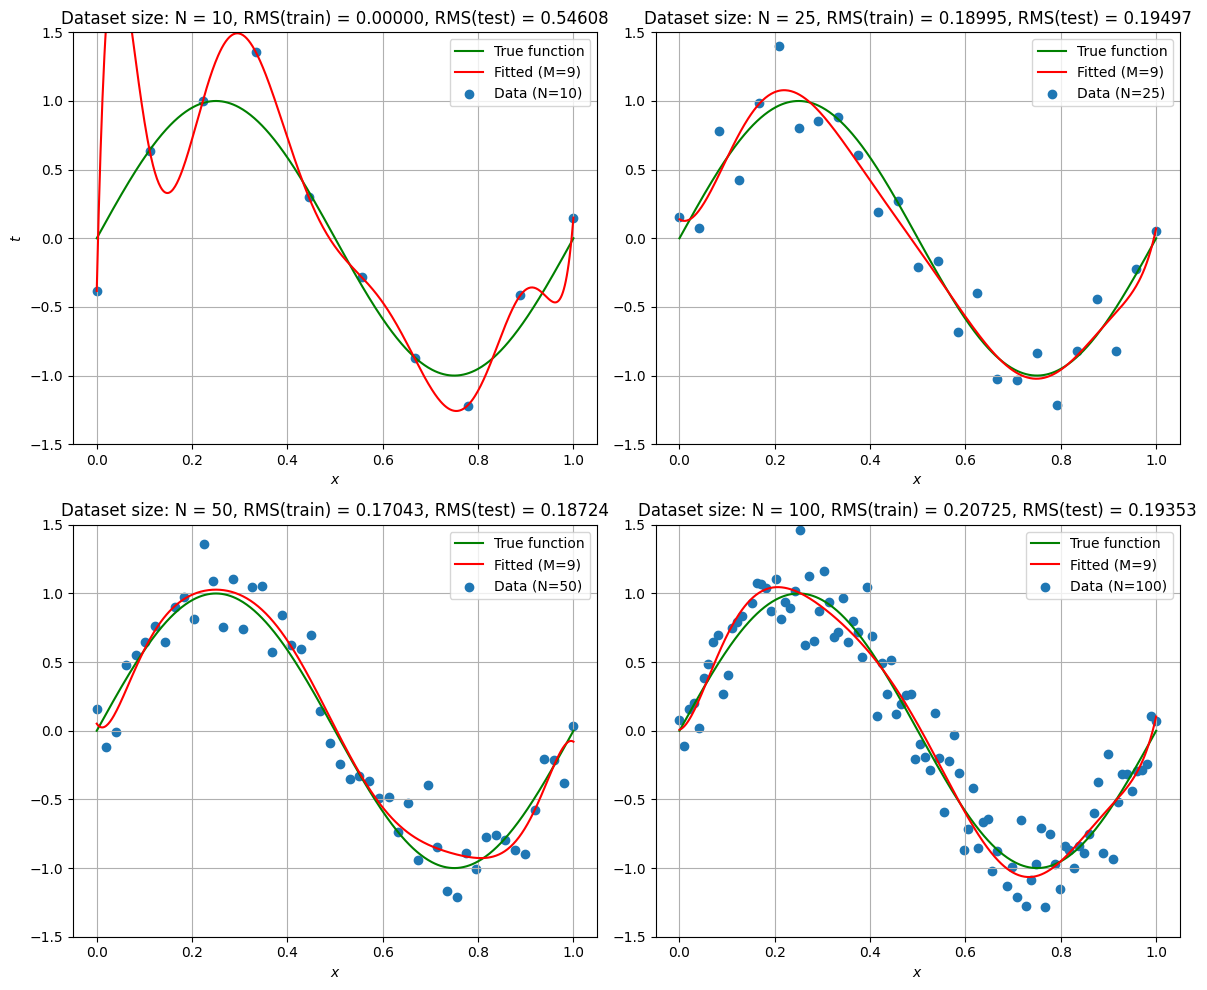

In [10]:
# Define dataset sizes to test
dataset_sizes = [10, 25, 50, 100]
M = 9
weights_dict = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes into a 1D array

for i, N in enumerate(dataset_sizes):
    # Generate a new training set of size N
    x_train, t_train = generate_data(N)

    # Fit the M=9 polynomial
    w_N = fit_polynomial(x_train, t_train, M)
    weights_dict[N] = w_N

    # Generate predictions for the smooth curve
    y_true = predict(x_true, w_N)

    # Plotting
    ax = axes[i]
    ax.plot(x_true, t_true, color='green', label='True function')
    ax.plot(x_true, y_true, color='red',   label=f'Fitted (M={M})')
    ax.scatter(x_train, t_train,           label=f'Data (N={N})')
    rms_train = np.sqrt(mse(predict(x_train, w_N), t_train))
    rms_test  = np.sqrt(mse(predict(x_test,  w_N), t_test))
    ax.set_title(f'Dataset size: N = {N}, RMS(train) = {rms_train:.5f}, RMS(test) = {rms_test:.5f}')
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel('$x$')
    if i == 0:
        ax.set_ylabel('$t$')
    ax.legend(loc='upper right')
    ax.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Display the learned coefficients for comparison
weights_df = pd.DataFrame(index=[f'w_{i}' for i in range(M + 1)])

for N in dataset_sizes:
    # Map the numpy array to a Series with matching index labels to prevent NaNs
    series = pd.Series(weights_dict[N], index=[f'w_{i}' for i in range(M + 1)])
    weights_df[f'N={N}'] = series

print("Table of Learned Coefficients (Notice the exploding values for N=10):")
weights_df.round(2)

Table of Learned Coefficients (Notice the exploding values for N=10):


,N=10,N=25,N=50,N=100
w_0,-0.38,0.14,0.05,0.01
w_1,150.29,-2.15,-5.07,1.11
w_2,-3124.33,108.46,260.73,146.45
w_3,26749.63,-405.69,-2455.91,-1282.80
w_4,-119486.44,-716.03,11765.03,4835.09
w_5,308590.46,7287.48,-33118.24,-9784.53
w_6,-478795.42,-18377.77,56013.78,10666.38
w_7,440605.58,22516.16,-55708.63,-5442.79
w_8,-221622.67,-13793.39,29975.76,497.23
w_9,46933.44,3382.88,-6727.57,363.96


**Observation:** Notice how the wild oscillations disappear as $N$ increases. By $N=100$, the $M=9$ polynomial provides an "good" fit to the true underlying function. The "noise" is averaged out by the sheer volume of data, forcing the model to capture the true underlying trend.



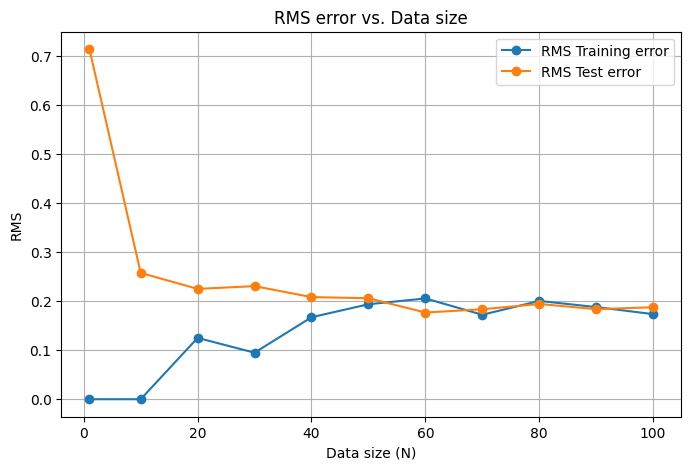

In [12]:
Ns  = np.linspace(1, 100, 11, dtype=int)
#Ns = [ 5, 7, 10, 14, 17, 22, 30, 40, 60, 80, 100 ]

rms_train = np.zeros(len(Ns))
rms_test  = np.zeros(len(Ns))

# Calculate RMS on all sets
for i, N in enumerate(Ns):
    # Generate a new training set of size N
    x_train, t_train = generate_data(N)

    # Fit the M=9 polynomial
    w_N = fit_polynomial(x_train, t_train, M)

    # Calculate RMS on all sets
    rms_train[i] = np.sqrt(mse(predict(x_train, w_N), t_train))
    rms_test[i]  = np.sqrt(mse(predict(x_test,  w_N), t_test ))

# Plot RMS error vs. Data size
plt.figure(figsize=(8, 5))
plt.plot(Ns, rms_train, '-o', label='RMS Training error')
plt.plot(Ns, rms_test,  '-o', label='RMS Test error')
plt.xlabel('Data size (N)')
plt.ylabel('RMS')
plt.title('RMS error vs. Data size')
plt.legend()
plt.grid(True)
plt.show()

## 7. Regularization (weight decay)

We just saw that one way to combat overfitting is to collect more data. But what if data is scarce?

Instead of artificially limiting the number of parameters $M$, we can use a technique called **regularization**. It modifies the error function by adding a penalty term that discourages the coefficients from growing too large:

$$
\tilde{E}(\boldsymbol{w}) = E(\boldsymbol{w}) + \frac{\lambda}{2} \|\boldsymbol{w}\|^2.
$$

Here, $\lambda$ (lambda) is a **hyperparameter**, that is, a parameter fixed *before* the optimization process, dictating the relative importance of the penalty term. This technique is referred to as **weight decay** because it encourages the network weights to decay toward zero.

The closed-form solution with regularization becomes: $\boldsymbol{w} = (\lambda \boldsymbol{I} + \boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T t$.

Take into account that,  the coefficient $w_0$ is omitted from the regularizer because its inclusion causes the results to depend on the choice of origin for the target variable (Hastie, Tibshirani, and Friedman, 2009). However, we will do it in the following, for the sake of simplicity.

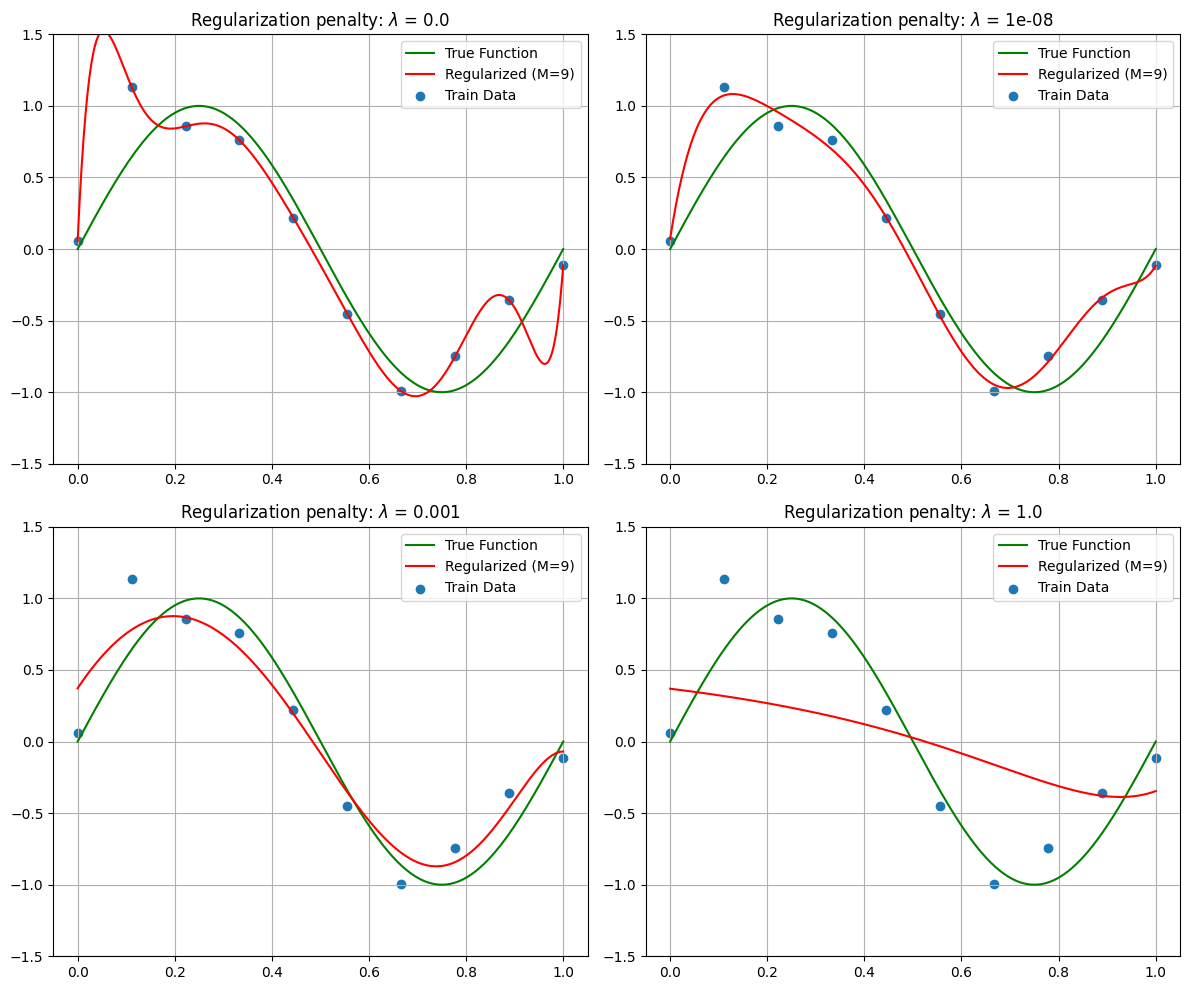

In [13]:
M = 9

# Generate a new training set of size N=10
N = 10
x_train, t_train = generate_data(N)

def fit_regularized_polynomial(x, t, M, lamda):
    """Solves for optimal weights w* in closed form.

    This implementation DOES regularize the bias term.
    """
    Phi = create_design_matrix(x, M)
    # Closed form solution with L2 regularization
    I = np.eye(M + 1)
    # Often w0 is omitted from regularization, but for simplicity we regularize
    # all weights. In this particular example, this is not a problem, since
    # mean(sin(2*pi*x) + noise) = 0

    '''
    try:
        w = np.linalg.inv(lamda*I + Phi.T@Phi) @ Phi.T @ t
    except:
        print(f'lambda = {lamda}')
        raise ValueError("Please increase lamda (λ) for regularization.")
    '''

    # NOTE: we use pinv instead of inv because internally it calculate the
    # generalized inverse of a matrix using its singular-value decomposition
    # (SVD) and including all large singular values. This may help in case
    # lambda_val*I + Phi.T@Phi is close to singular
    w = np.linalg.pinv(lamda*I + Phi.T@Phi) @ Phi.T @ t

    return w

from scipy.optimize import minimize
def fit_regularized_polynomial_with_scipy(x, t, M, lam):
    """Solves for optimal weights w* using Ridge Regression (Weight Decay),
    employing scipy.optimize.minimize

    This implementation does NOT regularize the bias term.
    """
    Phi = create_design_matrix(x, M)

    # Initial guess for weights
    w0_init = np.zeros(M + 1)

    def cost_function(w):
        predictions = Phi @ w

        # Mean Squared Error
        mse_val = 0.5*np.sum((predictions - t)**2)

        # L2 Regularization (excluding bias w0)
        reg_penalty = 0.5 * lam * np.sum(w[1:]**2)

        return mse_val + reg_penalty

    # Optimization using L-BFGS-B
    res = minimize(cost_function, w0_init, method="BFGS")
    return res.x


# lambda = 0.0  (No regularization)
# lambda = 1e-3 (Good regularization)
# lambda = 1.0  (Too much regularization)
lambdas = [0.0, 1e-8, 1e-3, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes into a 1D array

weights_dict = {}

for i, lam in enumerate(lambdas):
    w_reg = fit_regularized_polynomial(x_train, t_train, M, lam)
    #w_reg = fit_regularized_polynomial_with_scipy(x_train, t_train, M, lam)
    weights_dict[lambdas[i]] = w_reg
    y_true = predict(x_true, w_reg)

    ax = axes[i]
    ax.plot(x_true, t_true, color='green', label='True Function')
    ax.plot(x_true, y_true, color='red',   label=f'Regularized (M={M})')
    ax.scatter(x_train, t_train,           label='Train Data')
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(rf'Regularization penalty: $\lambda$ = {lambdas[i]}')
    ax.legend(loc='upper right')
    ax.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Observe how Regularization shrunk the weights
weights_df = pd.DataFrame(index=[f'w_{i}' for i in range(M + 1)])

for lam in lambdas:
    series = pd.Series(weights_dict[lam], index=[f'w_{i}' for i in range(M + 1)])
    weights_df[rf'λ={lam}'] = series

print("Coefficient Shrinkage due to Regularization:")
weights_df.round(2)

Coefficient Shrinkage due to Regularization:


,λ=0.0,λ=1e-08,λ=0.001,λ=1.0
w_0,0.06,0.07,0.37,0.37
w_1,72.67,21.67,5.11,-0.42
w_2,-1272.90,-166.92,-12.55,-0.40
w_3,9990.11,572.29,-2.98,-0.25
w_4,-43108.71,-889.27,3.80,-0.11
w_5,111058.37,235.85,6.00,-0.01
w_6,-175706.27,651.93,5.02,0.06
w_7,167331.47,-109.46,2.21,0.11
w_8,-87892.52,-680.04,-1.50,0.14
w_9,19527.61,363.77,-5.54,0.17


Lets create a plot that illustrates the effect of the regularization coefficient $\lambda$ on the RMS error:

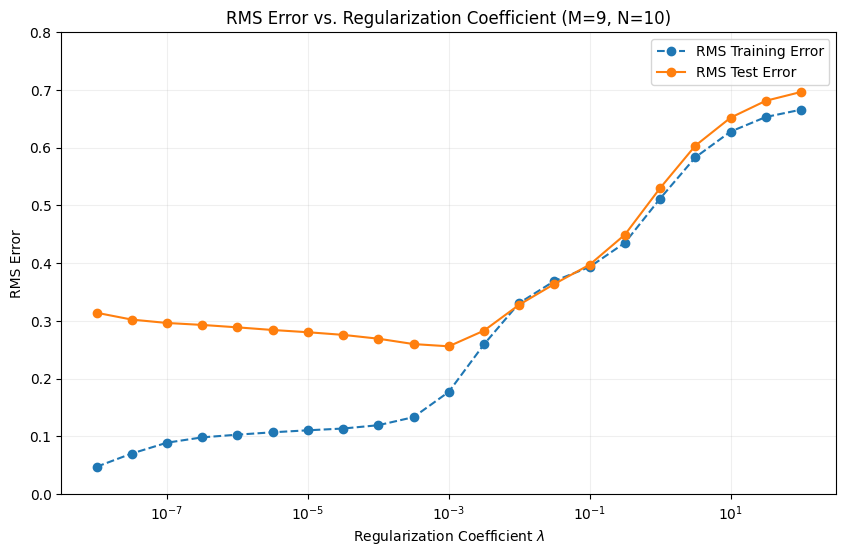

In [15]:
# Define a range of lambda values to test
Nlambdas = 21
lambdas = np.logspace(-8, 2, Nlambdas) # From 10^-8 to 10^2

rms_train = np.zeros(Nlambdas)
rms_test  = np.zeros(Nlambdas)

# Calculate RMS for each lambda
for i, lam in enumerate(lambdas):
    # Fit the regularized M=9 polynomial using the existing x_train, t_train, and M
    w_reg = fit_regularized_polynomial(x_train, t_train, M, lam)

    # Calculate RMS on training and test sets
    rms_train[i] = np.sqrt(mse(predict(x_train, w_reg), t_train))
    rms_test[i]  = np.sqrt(mse(predict(x_test,  w_reg), t_test))

# Plot RMS vs. Lambda
plt.figure(figsize=(10, 6))
plt.plot(lambdas, rms_train, '--o', label='RMS Training Error')
plt.plot(lambdas, rms_test,  '-o',  label='RMS Test Error')
plt.xscale('log') # Use a logarithmic scale for lambda
plt.xlabel(r'Regularization Coefficient $\lambda$')
plt.ylabel('RMS Error')
plt.title('RMS Error vs. Regularization Coefficient (M=9, N=10)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.ylim(0, 0.8) # Set a reasonable y-limit for better visualization
plt.show()

## 8. $K$-fold Cross-Validation

If our dataset is very small, partitioning a separate validation set might leave too little data to properly train on, and the validation results might be noisy.

A robust solution is **$S$-fold cross-validation**. We partition the available data into $K$ equal-sized groups (folds). We train the model on $K-1$ groups and validate on the single remaining group. We repeat this procedure $S$ times, holding out a different fold each time, and then average the performance scores across all runs. This effectively utilizes $(K-1)/K$ of the data for training while assessing performance across the entire dataset.

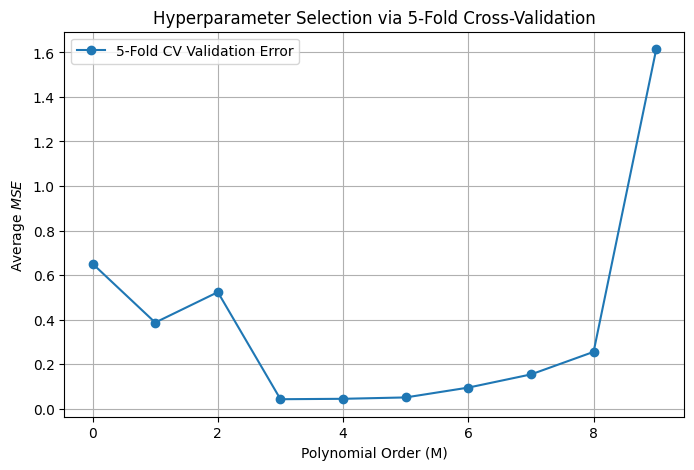

Based on Cross-Validation, the optimal polynomial order is M = 3


In [16]:
def K_fold_cross_validation(x, t, M, K=5):
    """Performs S-Fold Cross Validation manually to demonstrate mechanics."""
    # Shuffle indices
    indices = np.random.permutation(len(x))
    fold_size = len(x)//K

    val_errors = np.zeros(K)

    for s in range(K):
        # Identify validation fold indices
        valid_idx = indices[s*fold_size : (s + 1)*fold_size]
        # Identify training fold indices (everything else)
        train_idx = np.setdiff1d(indices, valid_idx)

        # Partition data
        x_train_fold, t_train_fold = x[train_idx], t[train_idx]
        x_valid_fold, t_valid_fold = x[valid_idx], t[valid_idx]

        # Train and Evaluate
        w = fit_polynomial(x_train_fold, t_train_fold, M)
        val_errors[s] = mse(predict(x_valid_fold, w), t_valid_fold)

    return np.mean(val_errors)

# Generate a slightly larger set for cross-validation demonstration
x_train, t_train = generate_data(20)
K = 5
cv_errors = [ K_fold_cross_validation(x_train, t_train, M, K) for M in range(10) ]

plt.figure(figsize=(8, 5))
plt.plot(cv_errors, '-o', label=f'{K}-Fold CV Validation Error')
plt.xlabel('Polynomial Order (M)')
plt.ylabel('Average $MSE$')
plt.title(f'Hyperparameter Selection via {K}-Fold Cross-Validation')
plt.legend()
plt.grid(True)
plt.show()

best_M = np.argmin(cv_errors)
print(f"Based on Cross-Validation, the optimal polynomial order is M = {best_M}")

## 9. The Bias-Variance Tradeoff

The error of a machine learning model can be decomposed into two main components:

* **Bias (Underfitting):** Measures how far off the average model prediction is from the correct value. High bias means the model is too simple (e.g., fitting a straight line to curvy data) and misses relevant relationships.
* **Variance (Overfitting):** Measures how much the model's prediction fluctuates for different training data. High variance means the model is too complex and captures noise or random patterns in the training data rather than the actual signal.

The Tradeoff:
* **Simple Models:** Often have high bias but low variance (e.g., Linear Regression).
* **Complex Models:** Often have low bias but high variance (e.g., Decision Trees).

By averaging the results of many models trained on different datasets of the same size, we can visualize this tradeoff.

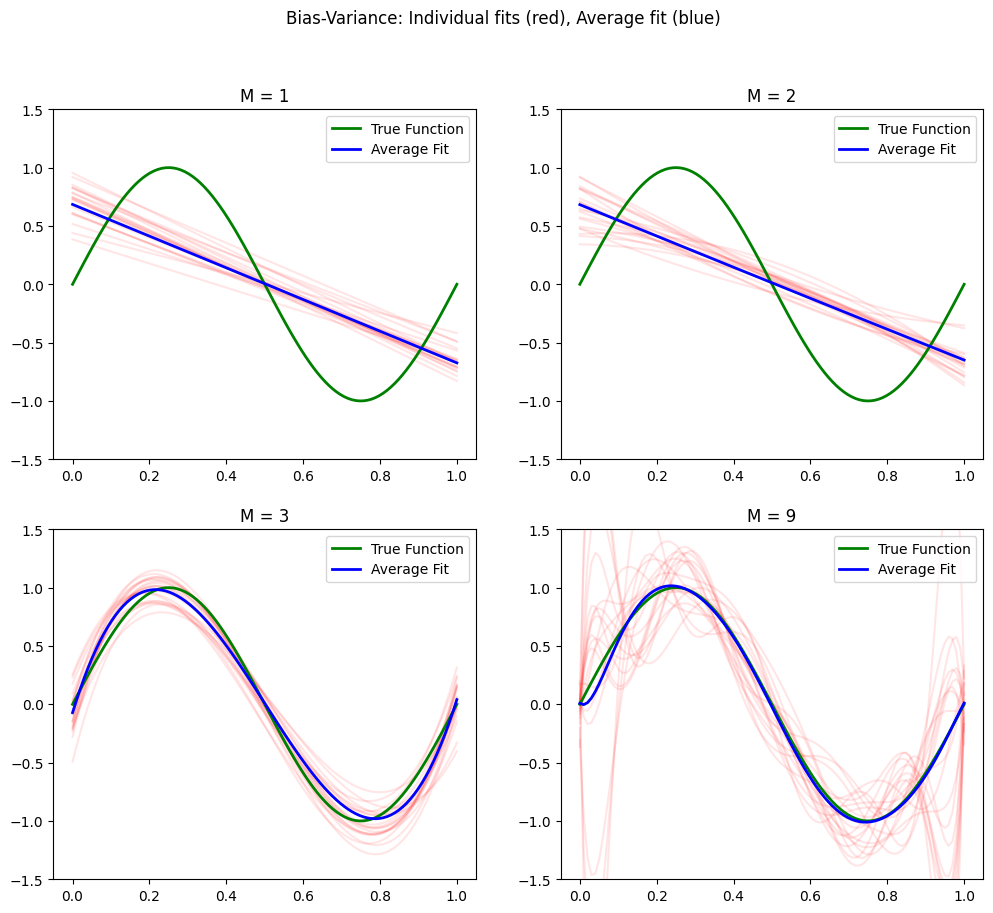

In [17]:
L = 100   # Number of datasets
N =  10   # Points per dataset
M_values = [1, 2, 3, 9]

x_true = np.linspace(0, 1, 100)
t_true = true_function(x_true)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes into a 1D array

for i, M in enumerate(M_values):
    all_y = np.zeros((L, len(x_true)))
    for el in range(L):
        x, t = generate_data(N)
        w = fit_polynomial(x, t, M)
        y = predict(x_true, w)
        all_y[el] = y
        if el < 20: # Plot first 20 individual fits
            axes[i].plot(x_true, y, color='red', alpha=0.1)

    y_avg = np.mean(all_y, axis=0)
    axes[i].plot(x_true, t_true, color='green', label='True Function', linewidth=2)
    axes[i].plot(x_true, y_avg,  color='blue',  label='Average Fit',   linewidth=2)
    axes[i].set_title(f'M = {M}')
    axes[i].set_ylim(-1.5, 1.5)
    axes[i].legend()

plt.suptitle('Bias-Variance: Individual fits (red), Average fit (blue)')
plt.show()

### Regularization and the Tradeoff
Now let's see how regularization (weight decay) affects the M=9 model. By increasing $\lambda$, we increase bias but significantly reduce variance.

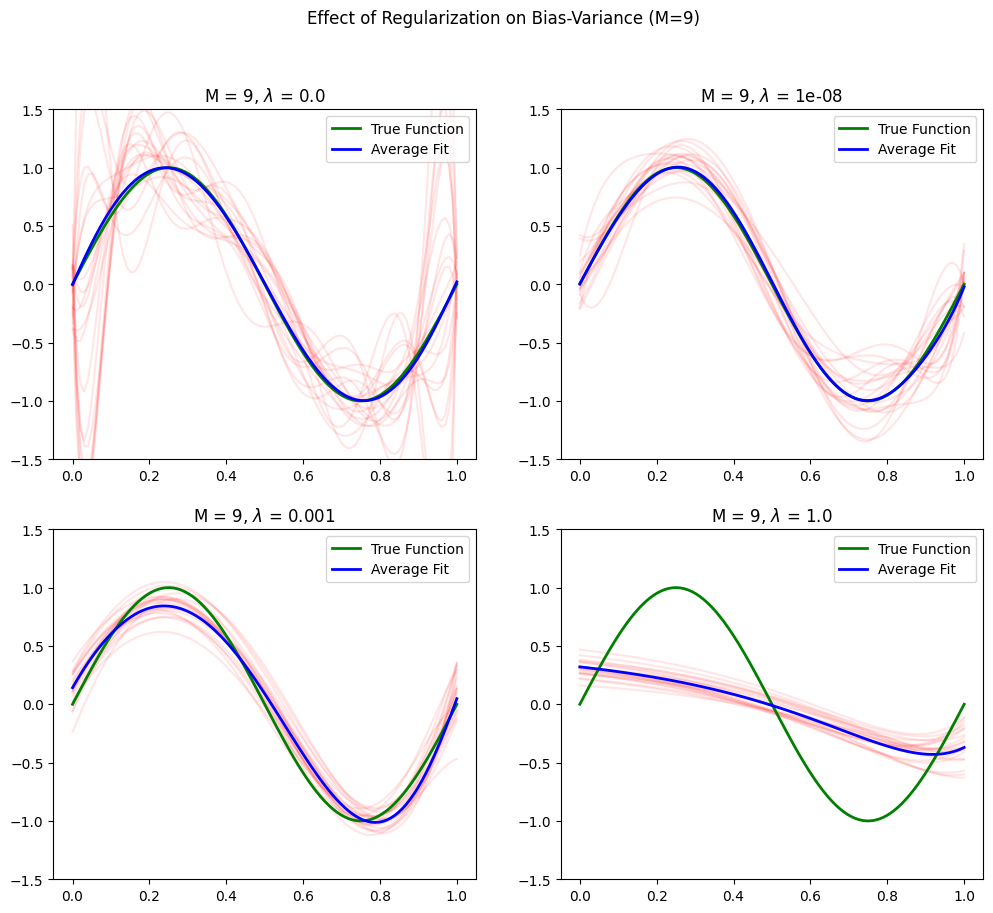

In [18]:
lambdas = [0.0, 1e-8, 1e-3, 1.0]
M = 9

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes into a 1D array

for i, lam in enumerate(lambdas):
    all_y = np.zeros((L, len(x_true)))
    for el in range(L):
        x, t = generate_data(N)
        w = fit_regularized_polynomial(x, t, M, lam)
        y = predict(x_true, w)
        all_y[el] = y
        if el < 20:
            axes[i].plot(x_true, y, color='red', alpha=0.1)

    y_avg = np.mean(all_y, axis=0)
    axes[i].plot(x_true, t_true, color='green', label='True Function', linewidth=2)
    axes[i].plot(x_true, y_avg,  color='blue',  label='Average Fit',   linewidth=2)
    axes[i].set_title(rf'M = 9, $\lambda$ = {lam}')
    axes[i].set_ylim(-1.5, 1.5)
    axes[i].legend()

plt.suptitle('Effect of Regularization on Bias-Variance (M=9)')
plt.show()

## 10. Bayesian Linear Regression

In Bayesian linear regression, we treat the weights $\boldsymbol{w}$ as random variables, not fixed parameters. We define a prior probability distribution over $\boldsymbol{w}$ and, after observing the data, update this belief to a posterior distribution using Bayes' theorem.

### Prior Distribution
We typically assume a Gaussian prior over the weights:
$$
p(\boldsymbol{w}) = \mathcal{N}(\boldsymbol{w} | \boldsymbol{m}_0, \boldsymbol{S}_0),
$$
where $\boldsymbol{m}_0$ is the prior mean and $\boldsymbol{S}_0$ is the prior covariance. For simplicity, we often use a zero-mean isotropic Gaussian prior:
$$
p(\boldsymbol{w} | \alpha) = \mathcal{N}(\boldsymbol{w} | \boldsymbol{0}, \alpha^{-1}\boldsymbol{I}),
$$
where $\alpha$ is the precision parameter of the prior.

### Likelihood Function
Assuming Gaussian noise with precision $\beta = 1/\sigma^2$, the likelihood of the target values $\boldsymbol{t}$ given $\boldsymbol{x}$, $\boldsymbol{w}$, and $\beta$ is:
$$
p(\boldsymbol{t} | \boldsymbol{x}, \boldsymbol{w}, \beta) = \prod_{n=1}^{N} \mathcal{N}(t_n | \boldsymbol{w}^T \boldsymbol{\phi}(x_n), \beta^{-1}),
$$
where $\boldsymbol{\phi}(x_n)$ is the basis function vector (e.g., $[1, x_n, x_n^2, ..., x_n^M]^T$).

### Posterior Distribution
Combining the Gaussian prior and Gaussian likelihood, the posterior distribution over the weights is also Gaussian:
$$
p(\boldsymbol{w} | \boldsymbol{t}, \boldsymbol{x}, \alpha, \beta) = \mathcal{N}(\boldsymbol{w} | \boldsymbol{m}_N, \boldsymbol{S}_N),
$$
where the posterior mean $\boldsymbol{m}_N$ and posterior covariance $\boldsymbol{S}_N$ are given by:
\begin{align*}
\boldsymbol{S}_N^{-1} &= \alpha \boldsymbol{I} + \beta \boldsymbol{\Phi}^T \boldsymbol{\Phi} \\
\boldsymbol{m}_N &= \beta \boldsymbol{S}_N \boldsymbol{\Phi}^T \boldsymbol{t}.
\end{align*}


In [19]:
def calculate_posterior_params(Phi, t, alpha, beta):
    """Calculates the posterior mean m_N and covariance S_N for weights w.

    Args:
        Phi (np.ndarray): Design matrix (N x M+1).
        t (np.ndarray): Target values (N,).
        alpha (float): Prior precision parameter.
        beta (float): Noise precision parameter.

    Returns:
        tuple: A tuple containing:
            - m_N (np.ndarray): Posterior mean of the weights (M+1,).
            - S_N (np.ndarray): Posterior covariance matrix of the weights (M+1, M+1).
    """
    M_plus_1 = Phi.shape[1]
    S_N_inv = alpha * np.eye(M_plus_1) + beta * Phi.T @ Phi
    S_N = np.linalg.inv(S_N_inv)
    m_N = beta * S_N @ Phi.T @ t
    return m_N, S_N


### Predictive Distribution
The predictive distribution for a new input $\boldsymbol{x}^*$ is also Gaussian, which allows us to quantify the uncertainty in our predictions:
$$
p(t^* | \boldsymbol{x}^*, \boldsymbol{x}, \boldsymbol{t}, \alpha, \beta) = \mathcal{N}\left(t^* | m_N(\boldsymbol{x}^*), \sigma_N^2(\boldsymbol{x}^*)\right),
$$
where the predictive mean $m(\boldsymbol{x}^*)$ and predictive variance $\sigma^2(\boldsymbol{x}^*)$ are:
\begin{align*}
m_N(\boldsymbol{x}^*) &= \boldsymbol{m}_N^T \boldsymbol{\phi}(\boldsymbol{x}^*) \\
\sigma_N^2(\boldsymbol{x}^*) &= \frac{1}{\beta} + \boldsymbol{\phi}(\boldsymbol{x}^*)^T \boldsymbol{S}_N \boldsymbol{\phi}(\boldsymbol{x}^*).
\end{align*}

The term $1/\beta$ represents the noise variance, and the second term reflects the uncertainty in the weights $\boldsymbol{w}$.

In [20]:
def predictive_distribution(Phi_new, m_N, S_N, beta):
    """Calculates the predictive mean and variance for new inputs.

    Args:
        Phi_new (np.ndarray): Design matrix for new inputs (N_new x M+1).
        m_N (np.ndarray): Posterior mean of the weights (M+1,).
        S_N (np.ndarray): Posterior covariance matrix of the weights (M+1, M+1).
        beta (float):     Noise precision parameter.

    Returns:
        tuple: A tuple containing:
            - m_N_x_ast  (np.ndarray): Predictive mean     (N_new,).
            - s2_N_x_ast (np.ndarray): Predictive variance (N_new,).
    """
    # Predictive mean
    m_N_x_ast = m_N @ Phi_new.T

    # Predictive variance: 1/beta (noise) + uncertainty in weights
    # s2_N_x_ast = (1/beta) + Phi_new.T @ S_N @ Phi_new
    s2_N_x_ast = (1/beta) + np.diag(Phi_new @ S_N @ Phi_new.T)

    return m_N_x_ast, s2_N_x_ast

Let's illustrate the algorithm:

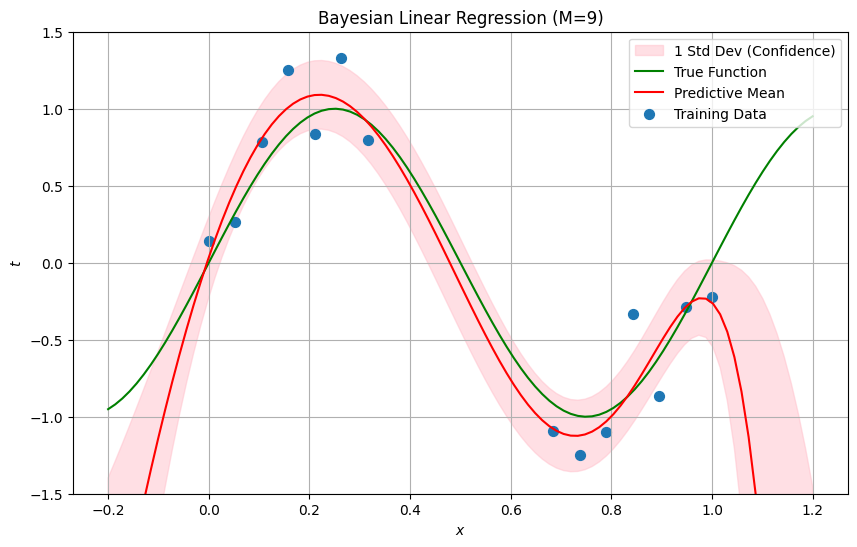

In [21]:
# Parameters
M = 9

# Prepare data
std_dev_noise = 0.2
x_train, t_train = generate_data(20, std_dev_noise)

# Precisions (1/variance)
alpha = 1e-3                  # Prior precision
beta  = 1/(std_dev_noise**2)  # Likelihood precision

# Define the range of indices to remove (7 to 13)
indices_to_remove = np.arange(7, 13)

# Remove points from x_train and t_train
x_train_cleaned = np.delete(x_train, indices_to_remove)
t_train_cleaned = np.delete(t_train, indices_to_remove)

# Update the original variables
x_train = x_train_cleaned
t_train = t_train_cleaned

x_true = np.linspace(-0.2, 1.2, 100)
t_true = true_function(x_true)

Phi_train = create_design_matrix(x_train, M)
Phi_test  = create_design_matrix(x_true,  M)

# Fit Bayesian model
m_N, S_N = calculate_posterior_params(Phi_train, t_train, alpha, beta)

# Predict
mu, sigma2 = predictive_distribution(Phi_test, m_N, S_N, beta)
std = np.sqrt(sigma2)

# Plotting results
plt.figure(figsize=(10, 6))
plt.fill_between(x_true, mu - std, mu + std, color='pink', alpha=0.5, label='1 Std Dev (Confidence)')
plt.plot(   x_true,  t_true,  label='True Function',   color='green')
plt.plot(   x_true,  mu,      label='Predictive Mean', color='red', )
plt.scatter(x_train, t_train, label="Training Data",   s=50)
plt.title(f'Bayesian Linear Regression (M={M})')
plt.xlabel('$x$')
plt.ylabel('$t$')
plt.ylim(-1.5, 1.5)
plt.legend()
plt.grid(True)
plt.show()